# 03 モニタリング候補の自動判定

## 目的

02の分析では、Penごとの前日変化量やPen間差を利用することで、
通常とは異なる変化を示す日を抽出できることを確認した。

また、Pen間差が急激に拡大した場合でも、
翌日に元の水準へ戻る一時的な変化と、
大きなPen間差が複数日にわたって継続する変化が確認された。

本Notebookでは、これらの特徴を利用して、

- 急激な変化が発生した日を検出する
- 変化後の状態が継続しているか確認する
- 一時的な変化と継続的な変化を分類する

ための簡易的なモニタリング判定方法を検討する。

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

trial1 = pd.read_csv(
    PROJECT_ROOT / "data" / "interim" / "trial1_daily_quality_summary.csv",
    parse_dates=["date"]
)

trial2 = pd.read_csv(
    PROJECT_ROOT / "data" / "interim" / "trial2_daily_quality_summary.csv",
    parse_dates=["date"]
)

trial1["trial"] = "Trial 1"
trial2["trial"] = "Trial 2"

daily = pd.concat(
    [trial1, trial2],
    ignore_index=True
).sort_values(
    ["trial", "pen", "date"]
).reset_index(drop=True)

print("Trial 1:", trial1.shape)
print("Trial 2:", trial2.shape)

display(daily.head())

Trial 1: (102, 8)
Trial 2: (107, 8)


,date,pen,count,min_mass,median_mass,max_mass,over_10kg,trial
0,2019-06-19,1,546957,-0.43,-0.30,82.15,1166,Trial 1
1,2019-06-20,1,789613,-0.47,-0.34,-0.10,0,Trial 1
2,2019-06-21,1,789646,-0.47,-0.23,0.82,0,Trial 1
3,2019-06-22,1,789699,-0.33,-0.12,1.73,0,Trial 1
4,2019-06-23,1,789675,-0.29,0.31,3.57,0,Trial 1


In [2]:
# 日ごとのPen間差を作成
pen_spread = (
    daily
    .groupby(["trial", "date"])
    .agg(
        min_pen_mass=("median_mass", "min"),
        max_pen_mass=("median_mass", "max"),
        pen_count=("pen", "nunique")
    )
    .reset_index()
)

# 最大値 - 最小値
pen_spread["pen_spread"] = (
    pen_spread["max_pen_mass"]
    - pen_spread["min_pen_mass"]
)

# Trial開始からの日数
pen_spread["day"] = (
    pen_spread
    .groupby("trial")["date"]
    .transform(lambda x: (x - x.min()).dt.days + 1)
)

# Pen間差の前日からの変化
pen_spread["spread_change"] = (
    pen_spread
    .groupby("trial")["pen_spread"]
    .diff()
)

display(
    pen_spread[
        [
            "trial",
            "date",
            "day",
            "pen_count",
            "pen_spread",
            "spread_change"
        ]
    ].head(15)
)

,trial,date,day,pen_count,pen_spread,spread_change
0,Trial 1,2019-06-19,1,3,0.08,NaN
1,Trial 1,2019-06-20,2,3,0.24,0.16
2,Trial 1,2019-06-21,3,3,0.27,0.03
3,Trial 1,2019-06-22,4,3,0.09,-0.18
4,Trial 1,2019-06-23,5,3,0.82,0.73
5,Trial 1,2019-06-24,6,3,0.93,0.11
6,Trial 1,2019-06-25,7,3,1.02,0.09
7,Trial 1,2019-06-26,8,3,1.08,0.06
8,Trial 1,2019-06-27,9,3,28.15,27.07
9,Trial 1,2019-06-28,10,3,0.83,-27.32


In [3]:
spread_change_stats = (
    pen_spread
    .groupby("trial")["spread_change"]
    .describe(
        percentiles=[0.5, 0.75, 0.9, 0.95]
    )
)

display(spread_change_stats)

,count,mean,std,min,50%,75%,90%,95%,max
trial,,,,,,,,,
Trial 1,33.0,1.116364,9.181023,-27.32,0.25,2.57,4.656,20.302,27.070
Trial 2,35.0,0.400429,2.063116,-3.46,0.21,1.16,2.622,4.427,6.275


In [4]:
# TrialごとのPen間差変化量の95%点
spread_thresholds = (
    pen_spread
    .groupby("trial")["spread_change"]
    .quantile(0.95)
)

print(spread_thresholds)

# 各行にTrialごとのしきい値を付与
pen_spread["spread_threshold"] = (
    pen_spread["trial"].map(spread_thresholds)
)

# 急拡大候補
pen_spread["rapid_spread"] = (
    pen_spread["spread_change"]
    >= pen_spread["spread_threshold"]
)

rapid_candidates = pen_spread[
    pen_spread["rapid_spread"]
][
    [
        "trial",
        "date",
        "day",
        "pen_spread",
        "spread_change",
        "spread_threshold"
    ]
].reset_index(drop=True)

display(rapid_candidates)

trial
Trial 1    20.302
Trial 2     4.427
Name: spread_change, dtype: float64


,trial,date,day,pen_spread,spread_change,spread_threshold
0,Trial 1,2019-06-27,9,28.150,27.070,20.302
1,Trial 1,2019-07-03,15,32.540,25.510,20.302
2,Trial 2,2019-10-11,33,9.520,4.910,4.427
3,Trial 2,2019-10-14,36,14.165,6.275,4.427


In [5]:
# 急拡大候補について、発生日から3日後までを確認
followup_rows = []

for _, candidate in rapid_candidates.iterrows():
    trial = candidate["trial"]
    start_day = candidate["day"]

    followup = pen_spread[
        (pen_spread["trial"] == trial) &
        (pen_spread["day"].between(start_day, start_day + 3))
    ].copy()

    followup["candidate_day"] = start_day
    followup_rows.append(followup)

followup_data = pd.concat(
    followup_rows,
    ignore_index=True
)

display(
    followup_data[
        [
            "trial",
            "candidate_day",
            "date",
            "day",
            "pen_spread"
        ]
    ]
)

,trial,candidate_day,date,day,pen_spread
0,Trial 1,9,2019-06-27,9,28.150
1,Trial 1,9,2019-06-28,10,0.830
2,Trial 1,9,2019-06-29,11,1.450
3,Trial 1,9,2019-06-30,12,2.400
4,Trial 1,15,2019-07-03,15,32.540
5,Trial 1,15,2019-07-04,16,34.470
6,Trial 1,15,2019-07-05,17,34.720
7,Trial 1,15,2019-07-06,18,34.840
8,Trial 2,33,2019-10-11,33,9.520
9,Trial 2,33,2019-10-12,34,10.010


In [6]:
results = []

for _, candidate in rapid_candidates.iterrows():

    trial = candidate["trial"]
    candidate_day = candidate["day"]
    candidate_spread = candidate["pen_spread"]

    # 候補日の「翌日から3日間」
    after = pen_spread[
        (pen_spread["trial"] == trial) &
        (pen_spread["day"] > candidate_day) &
        (pen_spread["day"] <= candidate_day + 3)
    ]

    # 継続判定用の暫定基準
    persistence_threshold = candidate_spread * 0.5

    if len(after) < 3:
        classification = "Insufficient data"

    elif (after["pen_spread"] >= persistence_threshold).all():
        classification = "Persistent"

    else:
        classification = "Temporary"

    results.append({
        "trial": trial,
        "date": candidate["date"],
        "day": candidate_day,
        "pen_spread": candidate_spread,
        "persistence_threshold": persistence_threshold,
        "followup_days": len(after),
        "classification": classification
    })

detection_results = pd.DataFrame(results)

display(detection_results)

,trial,date,day,pen_spread,persistence_threshold,followup_days,classification
0,Trial 1,2019-06-27,9,28.150,14.0750,3,Temporary
1,Trial 1,2019-07-03,15,32.540,16.2700,3,Persistent
2,Trial 2,2019-10-11,33,9.520,4.7600,3,Persistent
3,Trial 2,2019-10-14,36,14.165,7.0825,0,Insufficient data


## 継続性の自動判定

Pen間差が急拡大した候補について、発生日の翌日から3日間の推移を確認した。

探索的な判定ルールとして、急拡大日のPen間差の50%以上が
その後3日間すべてで維持された場合を `Persistent`、
維持されなかった場合を `Temporary` とした。

また、候補日の後に3日分のデータが存在しない場合は
`Insufficient data` とし、無理に分類しないこととした。

### 判定結果

- Trial 1 / Day 9：Temporary
- Trial 1 / Day 15：Persistent
- Trial 2 / Day 33：Persistent
- Trial 2 / Day 36：Insufficient data

Trial 1では、02の分析で目視確認した
「Day 9は一時的な変化」「Day 15は継続的な変化」という特徴を、
簡易的な判定ルールによって再現することができた。

なお、「3日間」および「急拡大時の50%以上」という条件は
生物学的な異常基準ではなく、自動判定方法を検討するために設定した探索的なルールである。

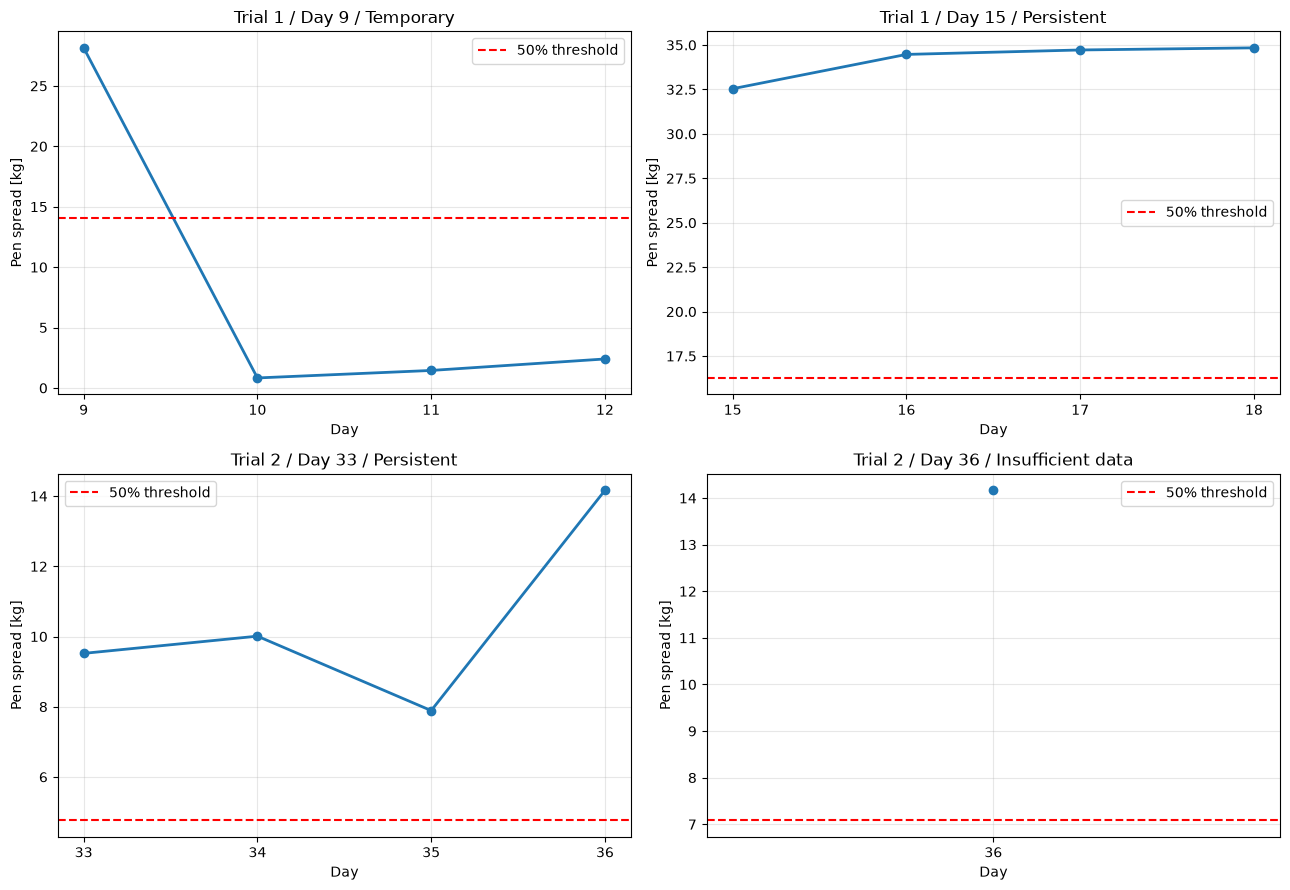

In [9]:
from pathlib import Path

image_dir = PROJECT_ROOT / "images"
image_dir.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (_, result) in zip(axes.flat, detection_results.iterrows()):

    trial = result["trial"]
    start_day = result["day"]

    # 候補日から3日後まで取得
    plot_data = pen_spread[
        (pen_spread["trial"] == trial) &
        (pen_spread["day"].between(start_day, start_day + 3))
    ]

    # Pen間差の推移
    ax.plot(
        plot_data["day"],
        plot_data["pen_spread"],
        marker="o",
        linewidth=2
    )

    # 継続判定の基準線
    ax.axhline(
        result["persistence_threshold"],
        color="red",
        linestyle="--",
        label="50% threshold"
    )

    ax.set_title(
        f"{trial} / Day {start_day} / {result['classification']}"
    )

    ax.set_xlabel("Day")
    ax.set_ylabel("Pen spread [kg]")
    ax.set_xticks(plot_data["day"])
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()

plt.savefig(
    image_dir / "monitoring_detection_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 分析結果と考察

### 1. モニタリング結果

Pen間のプラットフォーム荷重の差が急拡大した日を検出し、その後3日間の推移を確認した。

- Trial 1 / Day 9：翌日にPen間差が大きく縮小したため、一時的な変化（Temporary）と判定した。
- Trial 1 / Day 15：その後3日間も大きなPen間差が維持され、継続的な変化（Persistent）と判定した。
- Trial 2 / Day 33：その後3日間、基準以上のPen間差が続いたため、継続的な変化（Persistent）と判定した。
- Trial 2 / Day 36：最終日のため追跡データがなく、判定不能（Insufficient data）とした。

### 2. 考察

Trial 1では、一時的にPen間差が拡大した事例と、その後も差が継続した事例の両方が確認された。一方、Trial 2でも期間後半に継続的なPen間差の拡大がみられた。

急拡大した日だけでなく、その後の推移を確認することで、一時的な変動と継続的な差を区別できた。

### 3. 分析の限界と今後の課題

- 急拡大の検出基準にはTrialごとの前日差の95パーセンタイルを使用した。これは探索的に設定した基準であり、実際の異常を保証するものではない。
- 継続判定には候補日のPen間差の50%を基準として使用したが、この割合の妥当性は今後検証が必要である。
- プラットフォーム荷重の差は鶏の健康状態を直接示すものではなく、計測条件や飼育環境などの影響も考えられる。
- 最終日付近の候補は追跡データが不足するため、判定不能として扱う必要がある。

今後は検出基準の感度を確認し、実際の飼育状況や計測条件との関連を検討する。